In [32]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
import os
import copy
import time
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [33]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [34]:
class AdienceGenderDataset(Dataset):
    def __init__(self, fold_files, image_dir, transform=None):
        """
        Args:
            fold_files (list): List of fold data file paths
            image_dir (str): Directory with all the images
            transform (callable, optional): Optional transform to be applied on a sample
        """
        self.image_dir = image_dir
        self.transform = transform
        self.data = self._load_fold_data(fold_files)
        
    def _load_fold_data(self, fold_files):
        data = []
        for fold_file in fold_files:
            # Read the file with correct column names
            columns = ['user_id', 'original_image', 'face_id', 'age', 'gender', 
                      'x', 'y', 'dx', 'dy', 'tilt_ang', 'fiducial_yaw_angle', 'fiducial_score']
            df = pd.read_csv(fold_file, sep='\t', names=columns, skiprows=1)
            
            # Filter out rows with missing or invalid gender
            df = df[df['gender'].isin(['m', 'f'])]
            
            for _, row in df.iterrows():
                user_id = row['user_id']
                image_name = row['original_image']
                face_id = row['face_id']
                gender = 1 if row['gender'] == 'm' else 0  # m=1, f=0
                
                # Extract face coordinates, convert to int safely
                try:
                    x, y = int(float(row['x'])), int(float(row['y']))
                    dx, dy = int(float(row['dx'])), int(float(row['dy']))
                    
                    data.append({
                        'user_id': user_id,
                        'image_name': image_name,
                        'face_id': face_id,
                        'gender': gender,
                        'x': x, 'y': y, 'dx': dx, 'dy': dy
                    })
                except (ValueError, TypeError):
                    # Skip entries with invalid coordinates
                    continue
                    
        return data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        
        # Construct image path with the correct naming convention
        user_id = sample['user_id']
        image_name = sample['image_name']
        face_id = sample['face_id']
        
        # Format: landmark_aligned_face.[face_id].[original_image]
        aligned_image_name = f"landmark_aligned_face.{face_id}.{image_name}"
        image_path = os.path.join(self.image_dir, user_id, aligned_image_name)
        
        try:
            # Load image as RGB (no need to convert to grayscale)
            image = Image.open(image_path).convert('RGB')
            
            if self.transform:
                image = self.transform(image)
            
            return image, sample['gender']
        except Exception as e:
            # If image loading fails, return a placeholder
            print(f"Error loading image {image_path}: {e}")
            placeholder = torch.zeros((3, 128, 128))  # RGB placeholder
            return placeholder, sample['gender']

Training samples: 14047
Validation samples: 3445


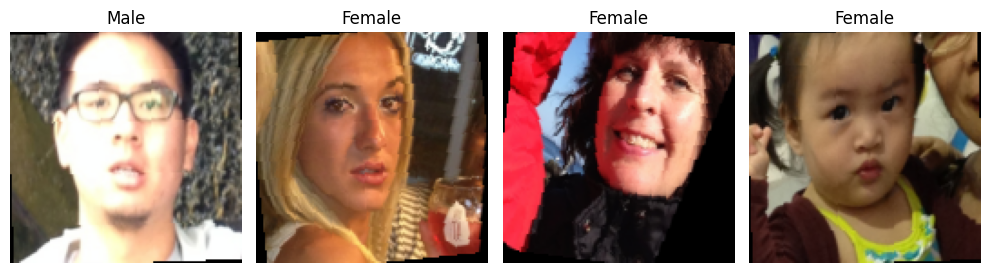

In [35]:
# Define data transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),  # Smaller size for faster processing
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet normalization
    ]),
    'val': transforms.Compose([
        transforms.Resize((128, 128)),  # Smaller size
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet normalization
    ]),
}


# Define paths
data_dir = 'AdienceGender'
image_dir = os.path.join(data_dir, 'aligned')  # Adjust based on your directory structure

# Use folds 0-3 for training and fold 4 for validation
train_fold_files = [os.path.join(data_dir, f'fold_{i}_data.txt') for i in range(0, 4)]
val_fold_files = [os.path.join(data_dir, 'fold_4_data.txt')]

# Create datasets
train_dataset = AdienceGenderDataset(train_fold_files, image_dir, transform=data_transforms['train'])
val_dataset = AdienceGenderDataset(val_fold_files, image_dir, transform=data_transforms['val'])

# Create data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=32,  # Larger batch size for faster training
    shuffle=True, 
    num_workers=0,  # Increase for faster data loading
    pin_memory=True  # Faster data transfer to GPU
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0,
    pin_memory=True
)

# Display dataset statistics
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Visualize some samples
def show_batch(dataloader, num_images=4):
    # Set a timeout for data loading
    timeout = 30  # seconds
    
    # Use a smaller batch size for visualization
    temp_loader = DataLoader(dataloader.dataset, batch_size=num_images, shuffle=True, num_workers=0)
    
    start_time = time.time()
    for images, labels in temp_loader:
        # Check if timeout exceeded
        if time.time() - start_time > timeout:
            print("Visualization timed out. Try reducing batch size further.")
            return
            
        # Create a smaller figure
        fig, ax = plt.subplots(figsize=(10, 3), nrows=1, ncols=num_images)
        
        for i in range(num_images):
            # Handle case where num_images=1
            curr_ax = ax[i] if num_images > 1 else ax
            
            img = images[i].permute(1, 2, 0).numpy()
            # Denormalize using ImageNet mean and std
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = np.clip(img, 0, 1)
            curr_ax.imshow(img)
            
            curr_ax.set_title(f"{'Male' if labels[i] == 1 else 'Female'}")
            curr_ax.axis('off')
            
        plt.tight_layout()
        break

# Don't forget to import time if not already imported
import time

# Show just 4 images
show_batch(train_loader, num_images=4)

In [36]:
# Define Multi-Scale Dilated Convolution Block
class MultiScaleDilatedBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiScaleDilatedBlock, self).__init__()
        
        # Multiple parallel dilated convolutions with different dilation rates
        self.dilation1 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=3, padding=1, dilation=1)
        self.dilation2 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=3, padding=2, dilation=2)
        self.dilation3 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=3, padding=4, dilation=4)
        self.dilation4 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=3, padding=8, dilation=8)
        
        # Batch normalization and activation
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        # Apply dilated convolutions in parallel
        d1 = self.dilation1(x)
        d2 = self.dilation2(x)
        d3 = self.dilation3(x)
        d4 = self.dilation4(x)
        
        # Concatenate the outputs
        out = torch.cat([d1, d2, d3, d4], dim=1)
        
        # Apply batch norm and activation
        out = self.bn(out)
        out = self.relu(out)
        
        return out

In [37]:
class DilatedResNet(nn.Module):
    def __init__(self, num_classes=2):
        super(DilatedResNet, self).__init__()
        
        # Load pre-trained ResNet-18
        resnet = models.resnet18(pretrained=True)
        
        # Use the first layer as-is (it already expects RGB)
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        # Use early layers from ResNet
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        
        # Replace later layers with dilated convolutions
        in_channels = 128  # Output channels from layer2
        
        # Multi-scale dilated blocks
        self.multi_scale1 = MultiScaleDilatedBlock(in_channels, 256)
        self.multi_scale2 = MultiScaleDilatedBlock(256, 512)
        
        # Global average pooling and classification
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # No need to check for grayscale anymore
        
        # ResNet early layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        
        # Multi-scale dilated convolutions
        x = self.multi_scale1(x)
        x = self.multi_scale2(x)
        
        # Classification
        x = self.avgpool(x)
        x = self.fc(x)
        
        return x

In [38]:
# Create the model
dilated_model = DilatedResNet(num_classes=2).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dilated_model.parameters(), lr=0.0005, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)

c:\Users\ruven\.conda\envs\elo_merchant\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ruven\.conda\envs\elo_merchant\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [39]:
# Training function
def train_model(model, dataloaders, criterion, optimizer, scheduler=None, num_epochs=25, device='cuda'):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterate over data
            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward pass - track history only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward + optimize only in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Save history
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            
            # Update scheduler based on validation loss
            if phase == 'val' and scheduler is not None:
                scheduler.step(epoch_loss)
            
            # Deep copy the model if it's the best validation accuracy so far
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        print()
    
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [40]:
# Create dataloaders dictionary
dataloaders = {
    'train': train_loader,
    'val': val_loader
}
# Train the model
dilated_model, dilated_history = train_model(
    dilated_model, 
    dataloaders, 
    criterion, 
    optimizer, 
    scheduler=scheduler,
    num_epochs=15,
    device=device
)

Epoch 1/15
----------


train: 100%|██████████| 439/439 [07:47<00:00,  1.06s/it]


train Loss: 0.3370 Acc: 0.8503


val: 100%|██████████| 108/108 [00:54<00:00,  2.00it/s]


val Loss: 0.4681 Acc: 0.7962

Epoch 2/15
----------


...

val Loss: 0.3581 Acc: 0.8897

Epoch 15/15
----------


train: 100%|██████████| 439/439 [07:42<00:00,  1.05s/it]


train Loss: 0.0467 Acc: 0.9848


val: 100%|██████████| 108/108 [00:54<00:00,  1.99it/s]

val Loss: 0.3171 Acc: 0.8984

Training complete in 130m 55s
Best val Acc: 0.8984
